# 06 — Spatial Analysis: COVID-19 Testing

State-level analysis of testing volume, positivity, testing intensity and testing burden. Uses the cleaned testing dataset.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_PATH = Path("C:\\Users\\admin\\Desktop\\covid-19\\data\\processed\\testing_clean.csv")
df = pd.read_csv(DATA_PATH)

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df = df.sort_values(["State", "Date"]).reset_index(drop=True)

print("Shape:", df.shape)
print("Date range:", df["Date"].min(), "to", df["Date"].max())
print("States:", df["State"].nunique())


Shape: (16335, 9)
Date range: 2020-04-01 00:00:00 to 2021-08-10 00:00:00
States: 36


## 1. Latest testing volume by state

,State,Date,TotalSamples,Positive
15350,Uttar Pradesh,2021-08-10,67897856.0,NaN
9375,Maharashtra,2021-08-10,49905065.0,NaN
7409,Karnataka,2021-08-10,40104915.0,NaN
13995,Tamil Nadu,2021-08-10,39002757.0,NaN
2375,Bihar,2021-08-10,38820518.0,NaN
7906,Kerala,2021-08-10,28745545.0,NaN
4965,Gujarat,2021-08-10,26192626.0,NaN
940,Andhra Pradesh,2021-08-10,25311733.0,NaN
3995,Delhi,2021-08-10,24333906.0,NaN
14414,Telangana,2021-08-10,22991849.0,NaN


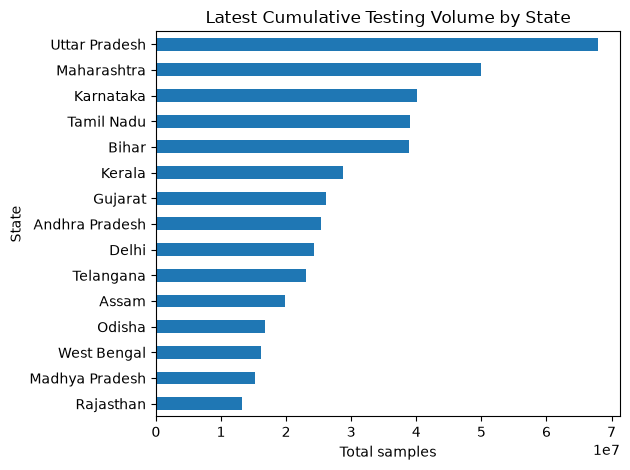

In [3]:
latest = (
    df.sort_values("Date")
      .groupby("State", as_index=False)
      .tail(1)
      [["State", "Date", "TotalSamples", "Positive"]]
      .sort_values("TotalSamples", ascending=False)
)

display(latest.head(15))

latest.head(15).set_index("State")["TotalSamples"].sort_values().plot(kind="barh")
plt.title("Latest Cumulative Testing Volume by State")
plt.xlabel("Total samples")
plt.tight_layout()
plt.show()


## 2. Cumulative positivity rate by state

In [4]:
state_testing = (
    df.groupby("State", as_index=False)
      .agg(
          TotalSamples=("TotalSamples", "max"),
          Positive=("Positive", "max")
      )
)

state_testing["CumulativePositivityRate_%"] = (
    state_testing["Positive"] / state_testing["TotalSamples"].replace(0, np.nan) * 100
)

display(
    state_testing.sort_values("CumulativePositivityRate_%", ascending=False)
    .head(15)
)


,State,TotalSamples,Positive,CumulativePositivityRate_%
19,Madhya Pradesh,15144644.0,791732.0,5.227802
32,Tripura,1630572.0,80413.0,4.931582
7,Dadra and Nagar Haveli and Daman and Diu,72410.0,3194.0,4.410993
20,Maharashtra,49905065.0,1638961.0,3.284158
16,Kerala,28745545.0,932639.0,3.244464
14,Jharkhand,12184347.0,346824.0,2.846472
26,Puducherry,1557320.0,44037.0,2.827743
11,Haryana,11135555.0,275137.0,2.470797
0,Andaman and Nicobar Islands,452587.0,7516.0,1.660675
24,Nagaland,280777.0,3558.0,1.267198


## 3. Testing intensity over time by state

In [5]:
df["NewTests"] = df.groupby("State")["TotalSamples"].diff()
df["NewTests_Valid"] = df["NewTests"].where(df["NewTests"] >= 0)

testing_activity = (
    df.groupby("State", as_index=False)
      .agg(
          Mean_NewTests=("NewTests_Valid", "mean"),
          Peak_NewTests=("NewTests_Valid", "max"),
          TotalSamples=("TotalSamples", "max")
      )
      .sort_values("Mean_NewTests", ascending=False)
)

display(testing_activity.head(15))


,State,Mean_NewTests,Peak_NewTests,TotalSamples
33,Uttar Pradesh,139413.186858,358273.0,67897856.0
20,Maharashtra,102665.981481,290207.0,49905065.0
15,Karnataka,81837.404082,189793.0,40104915.0
30,Tamil Nadu,79589.944898,182878.0,39002757.0
4,Bihar,79544.018443,205085.0,38820518.0
16,Kerala,57938.669355,199456.0,28745545.0
31,Telangana,54968.629187,147161.0,22991849.0
10,Gujarat,53885.600823,189902.0,26192626.0
1,Andhra Pradesh,51971.114990,116367.0,25311733.0
8,Delhi,50160.765914,114288.0,24333906.0


## 4. Peak testing activity

In [6]:
peak_testing = (
    df.loc[df["NewTests_Valid"].notna()]
      .sort_values("NewTests_Valid", ascending=False)
      [["Date", "State", "NewTests_Valid", "TotalSamples"]]
      .head(20)
)

display(peak_testing)


,Date,State,NewTests_Valid,TotalSamples
15274,2021-05-26,Uttar Pradesh,358273.0,47720703.0
15276,2021-05-28,Uttar Pradesh,358048.0,48426572.0
15275,2021-05-27,Uttar Pradesh,347821.0,48068524.0
15282,2021-06-03,Uttar Pradesh,340411.0,50405118.0
15278,2021-05-30,Uttar Pradesh,340096.0,49096724.0
15281,2021-06-02,Uttar Pradesh,331511.0,50064707.0
15277,2021-05-29,Uttar Pradesh,330056.0,48756628.0
15272,2021-05-24,Uttar Pradesh,326798.0,47063616.0
15280,2021-06-01,Uttar Pradesh,323795.0,49733196.0
15283,2021-06-04,Uttar Pradesh,318714.0,50723832.0


## 5. Testing positivity spatial ranking

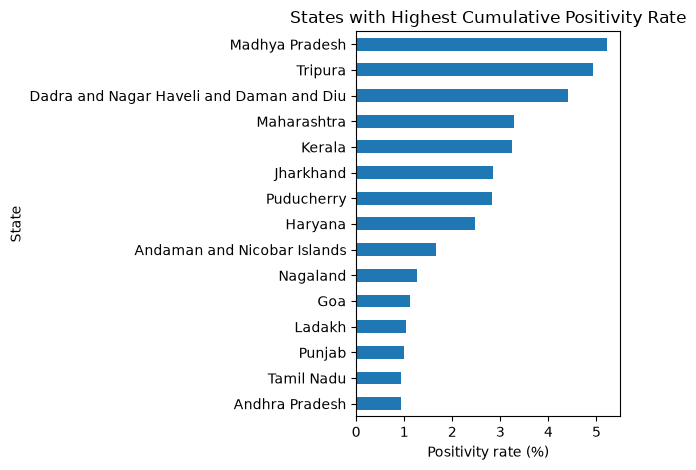

In [7]:
state_testing.sort_values("CumulativePositivityRate_%", ascending=False).head(15).set_index("State")["CumulativePositivityRate_%"].sort_values().plot(kind="barh")
plt.title("States with Highest Cumulative Positivity Rate")
plt.xlabel("Positivity rate (%)")
plt.tight_layout()
plt.show()


## 6. Testing volume vs positivity

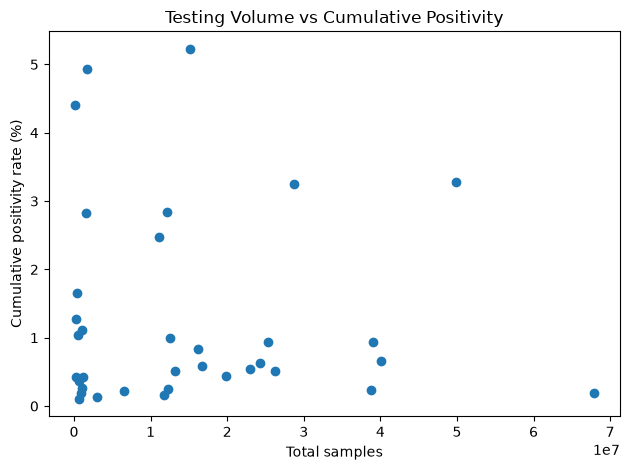

In [8]:
plt.scatter(
    state_testing["TotalSamples"],
    state_testing["CumulativePositivityRate_%"]
)
plt.xlabel("Total samples")
plt.ylabel("Cumulative positivity rate (%)")
plt.title("Testing Volume vs Cumulative Positivity")
plt.tight_layout()
plt.show()


## 7. Highest positive burden

In [9]:
display(
    state_testing.sort_values("Positive", ascending=False)
    [["State", "TotalSamples", "Positive", "CumulativePositivityRate_%"]]
    .head(15)
)


,State,TotalSamples,Positive,CumulativePositivityRate_%
20,Maharashtra,49905065.0,1638961.0,3.284158
16,Kerala,28745545.0,932639.0,3.244464
19,Madhya Pradesh,15144644.0,791732.0,5.227802
30,Tamil Nadu,39002757.0,367430.0,0.942062
14,Jharkhand,12184347.0,346824.0,2.846472
11,Haryana,11135555.0,275137.0,2.470797
15,Karnataka,40104915.0,264546.0,0.659635
1,Andhra Pradesh,25311733.0,235525.0,0.930497
8,Delhi,24333906.0,151928.0,0.624347
10,Gujarat,26192626.0,136004.0,0.519245


## 8. Spatial analysis cautions

In [10]:
print("Key spatial-analysis cautions:")
print("1. Testing data contains cumulative revisions, including negative NewTests.")
print("2. Negative changes are retained as revision flags but excluded from activity averages.")
print("3. Cumulative positivity is not the same as current daily positivity.")
print("4. States differ substantially in population and testing capacity.")
print("5. Population-normalized testing and positivity should be used when population data is available.")


Key spatial-analysis cautions:
1. Testing data contains cumulative revisions, including negative NewTests.
2. Negative changes are retained as revision flags but excluded from activity averages.
3. Cumulative positivity is not the same as current daily positivity.
4. States differ substantially in population and testing capacity.
5. Population-normalized testing and positivity should be used when population data is available.
